In [1]:
# Copy this into EVERY notebook's first cell
import sys
from pathlib import Path
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
  if Path("/content/drive").exists():
    print("Nothing to initialize, driver is already mounted!")
  else:
    from google.colab import drive
    drive.mount('/content/drive')
    colab_dir = f"/content/drive/MyDrive/colab"
    if colab_dir not in sys.path:
      sys.path.insert(0, colab_dir)
    from colab_setup import init
    paths = init("singular-learning-theory")
    print("Installing tex")
    !apt-get install texlive-fonts-recommended texlive-latex-extra texlive-pictures dvipng

  datadir = "/content/drive/MyDrive/colab/outputs/singular-learning-theory/mixtures/poisson2d"
else:
  from pathlib import Path
  paths = {'repo': Path.cwd(), 'output': Path.cwd() / 'outputs'}
  paths['output'].mkdir(exist_ok=True)
  print("📍 Running locally")
  from pathlib import Path

  ROOT = Path.cwd().parents[1]
  basedir = f"{ROOT}/mixture/poisson2d"

📍 Running locally


In [2]:
# Adjust the working directly to import packages using the root package
import sys
import os

notebook_dir = os.getcwd()
print(notebook_dir)
parent_dir = os.path.dirname(notebook_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/notebooks/poisson2d


In [3]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd

# from sklearn_extension.mixture import PoissonMixture
from sklearn.utils import resample

from IPython.display import display, clear_output
from tqdm.notebook import tqdm

from joblib import Parallel, delayed
import multiprocessing as mp
# from plot import visualize_joint_confidence_regions
import seaborn as sns
from matplotlib.lines import Line2D
import math

default_palette = "tab10"
# Enable LaTeX rendering
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

In [4]:
from pathlib import Path

try:
  import google.colab
  IN_COLAB = True

  # Cell 1 (Colab only - skip locally)
  !git clone https://github.com/RealAshrafAhmed/waterloo-slt-reading-group.git /content/repo
  %cd /content/repo
  !pip install uv && uv sync --all-packages
  
  # Cell 2 (both environments)
  from colab_extensions.env import setup
  env = setup()
  ROOT, DATA, OUTPUTS = env["ROOT"], env["DATA"], env["OUTPUTS"]
except ImportError:
  IN_COLAB = False
  ROOT = Path.cwd().parents[1]
  basedir = f"{ROOT}/outputs/mixture/poisson2d"
  datadir = f"{basedir}/data"
  outputdir = Path(f"{basedir}/posterior")


if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

Using datadir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/data
Using outputdir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior


In [5]:
dgps_file = Path(f"{datadir}/dgp.csv")
if dgps_file.exists():  # check if this data has already been generated
    print(f"File {dgps_file} exists, skipping experiments meta!.")
else:
    if dgps_file.parent:  # create parents dir if not already
        dgps_file.parent.mkdir(parents=True, exist_ok=True)

    dsids = ["regular", "e-singular", "singular1", "singular2"]
    dgps_raw = {
        "dsid": dsids,
        "m0": np.array([15, 15, 15, 5]),  # probability of per site mutation if MSI1 tumor
        "m1": np.array([1, 5, 5, 5]),  # probability of per site mutation if MSI2 tumor
        "w0": np.array(
            [0.75, 0.75, 1, 0.75]
        ),  # probability of selecting a person with MSI1 tumor
    }
    dgps_raw["w1"] = 1 - dgps_raw["w0"]
    pd.DataFrame(dgps_raw).set_index("dsid").to_csv(dgps_file)
    print(f"File {dgps_file} created!.")

dgps = pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/data/dgp.csv created!.


,dsid,m0,m1,w0,w1
0,regular,15,1,0.75,0.25
1,e-singular,15,5,0.75,0.25
2,singular1,15,5,1.00,0.00
3,singular2,5,5,0.75,0.25


In [6]:
from sklearn_extensions.mixture import mixpoisson_sample

num_replications = 1000  # number of samples per sample size
regimes = [50, 250, 5000]

for dsid in dgps["dsid"].unique():
  for regime in regimes:
    obs_file = Path(
        f"{datadir}/{dsid}-{regime}.csv"
    )  # where we are going to store observations
    if obs_file.exists():  # check if this data has already been generated
        print(f"File {obs_file} exists, skipping random samples creation!.")
    else:
        if obs_file.parent:  # create parents dir if not already
            obs_file.parent.mkdir(parents=True, exist_ok=True)
  
        results = {}
        for i in range(num_replications):
            dgp = dgps.query(f"dsid=='{dsid}'")
            mus = dgp[["m0", "m1"]].iloc[0].tolist()
            weights = dgp[["w0", "w1"]].iloc[0].tolist()
            samples = mixpoisson_sample(size=regime, weights=weights, mus=mus)
            results[f"r{i}"] = samples[0]
  
        data_df = pd.DataFrame(results)
        data_df.to_csv(obs_file, index=False)
        print(f"File {obs_file} created!.")


dsids = dgps["dsid"]
data = {}
for dsid in dsids:
  data[dsid]={}
  for regime in regimes:
    data[dsid][regime] = pd.read_csv(
        f"{datadir}/{dsid}-{regime}.csv", index_col=0
    ).reset_index()
  
print(f"loaded {list(data.keys())} samples")

File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/data/regular-50.csv created!.
File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/data/regular-250.csv created!.
File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/data/regular-5000.csv created!.
File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/data/e-singular-50.csv created!.
File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/data/e-singular-250.csv created!.
File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/data/e-singular-5000.csv created!.
File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/data/singular1-50.csv

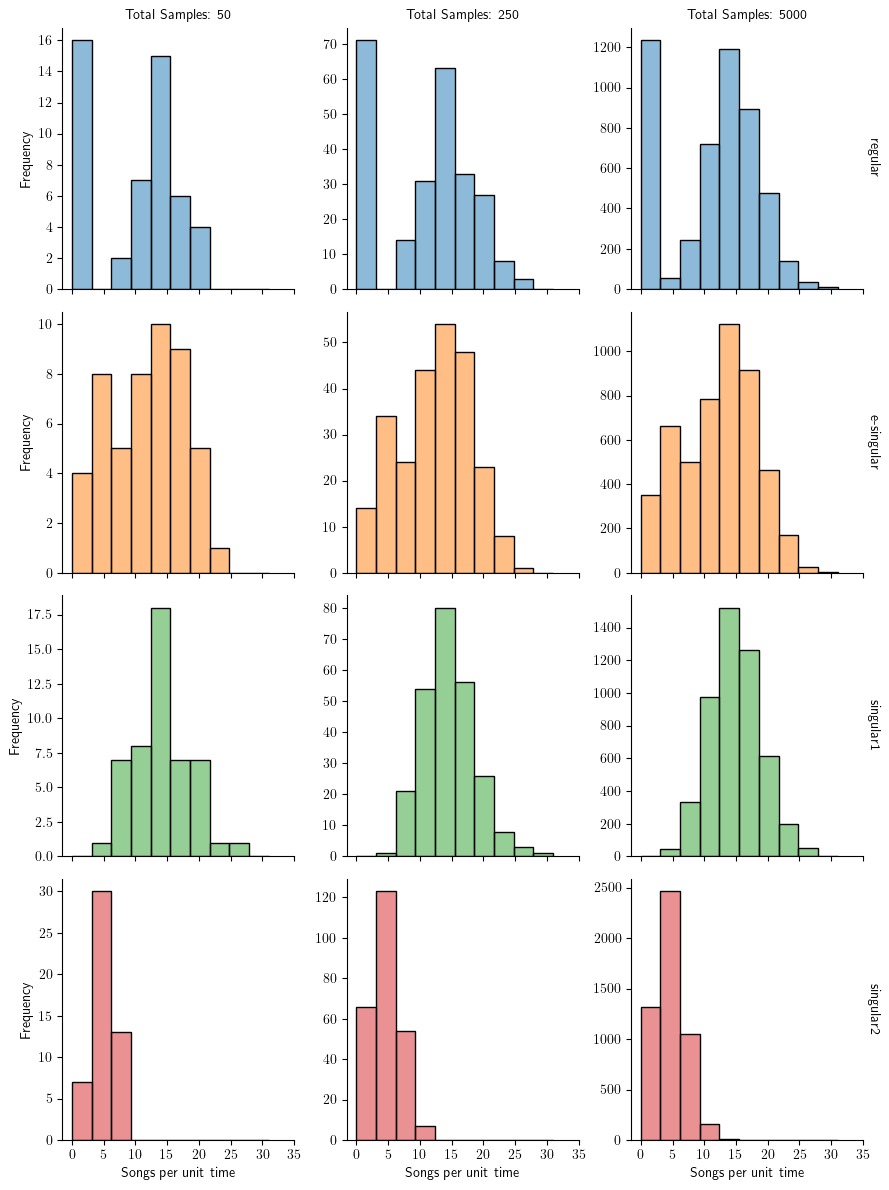

In [9]:
datasets = dgps["dsid"].unique()

# plot the data sets as different sample sizes
# we need to structure the plotting data for different sample sizes (keeping in mind that we are not regenerating the sample in each sample size)
plotdata = {"x": [], "size": [], "dsid": []} # raw data to initialize the plotting dataframe

for dsid in datasets:
    dgp = dgps.query(f"dsid == '{dsid}'")
    for ss in regimes:
        x = data[dsid][5000].iloc[:ss,1]
        plotdata["x"]=np.append(plotdata["x"], x)
        plotdata["size"]=np.append(plotdata["size"], (np.ones(ss)*ss).astype(int))
        plotdata["dsid"]=np.append(plotdata["dsid"], [dsid for i in np.ones(ss)])

plotdf = pd.DataFrame(plotdata)
plotdf = plotdf.astype({"x": int, "size": int, "dsid": str})
g=sns.displot(plotdf,
              x="x", col="size", row="dsid", hue="dsid",
              binwidth=3, height=3, facet_kws={"margin_titles": True, "sharey": False}, legend=False, palette=default_palette)

g.set_axis_labels("Songs per unit time", "Frequency")
g.set_titles(col_template="Total Samples: {col_name}", row_template=f"{{row_name}}")

for ax in g.axes.flat:
    ax.set_xticks(list(range(0, 40, 5)))

datasets_hist_file = Path(f'{basedir}/data/dataset_hist.png')
if datasets_hist_file.parent: # create parents dir if not already
    datasets_hist_file.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(datasets_hist_file, dpi=300, bbox_inches='tight')
plt.show()